**Name:** Manali Vijay Gaikwad

**PRN:** 2324000509

**TY(AIML) DIV:A-58**

**Assignment No. 5 – CNN model implementation on MNIST and CIFAR datasets**

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D

In [2]:
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

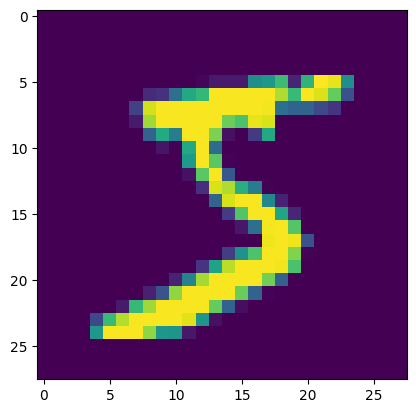

In [6]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])

In [7]:
x_train = x_train/255
x_test = x_test/255

In [8]:
# build cnn model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))
model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,554 (236.54 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 0 (0.00 B)

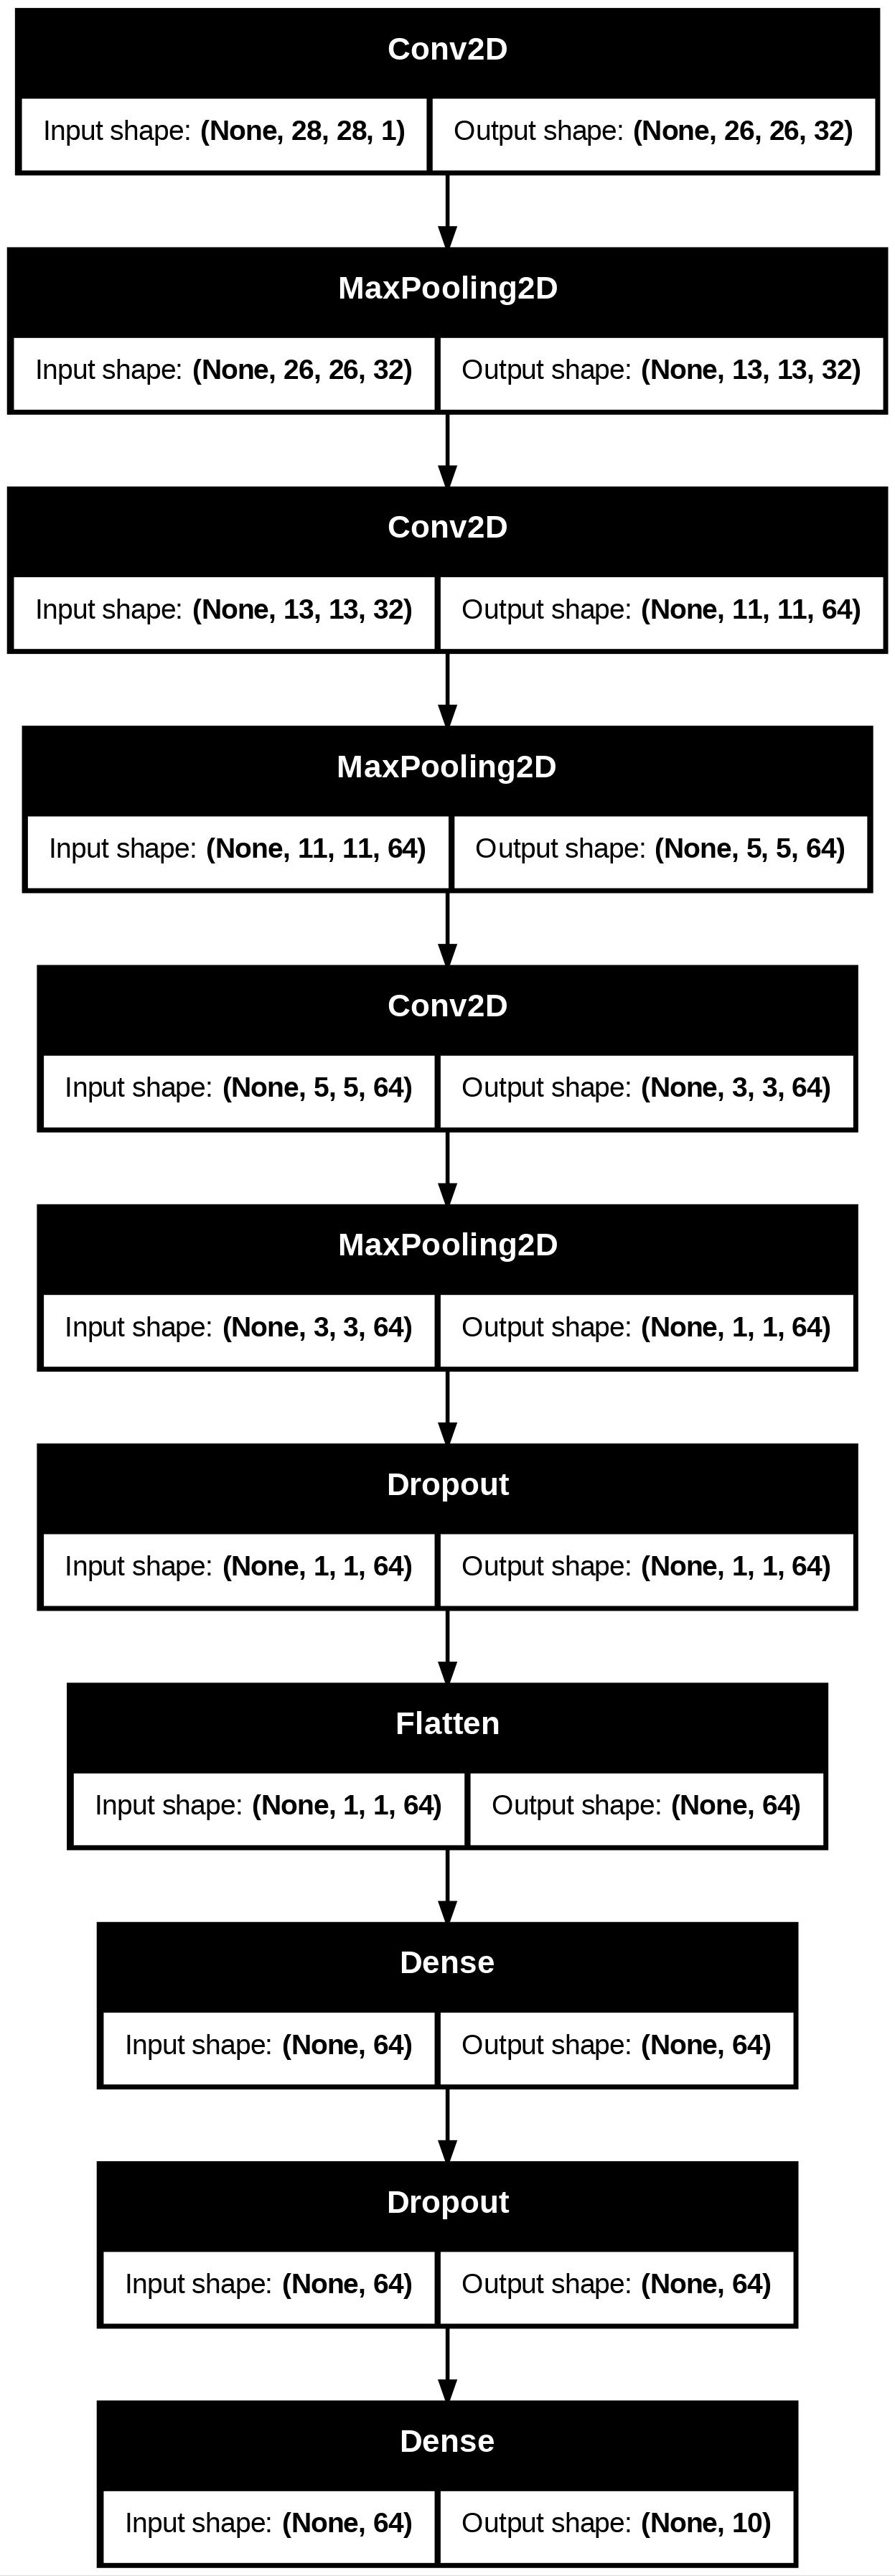

In [11]:
from keras.src.utils import plot_model
plot_model(model,'model.jpg',show_shapes=True)

In [12]:
model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 36ms/step - accuracy: 0.8266 - loss: 0.5452 - val_accuracy: 0.9674 - val_loss: 0.1060
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 32ms/step - accuracy: 0.9484 - loss: 0.1877 - val_accuracy: 0.9781 - val_loss: 0.0771
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9623 - loss: 0.1383 - val_accuracy: 0.9808 - val_loss: 0.0671
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9691 - loss: 0.1143 - val_accuracy: 0.9837 - val_loss: 0.0606
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.9729 - loss: 0.1018 - val_accuracy: 0.9852 - val_loss: 0.0574
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9772 - loss: 0.0857 - val_accuracy: 0.9845 - val_loss: 0.0619
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9786 - loss: 0.0740 - val_accuracy: 0.9846 - val_loss: 0.0559
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9813 -

In [13]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [14]:
y_pred =y_pred.argmax(axis=1)

In [15]:
y_pred

array([7, 2, 1, ..., 4, 5, 6])

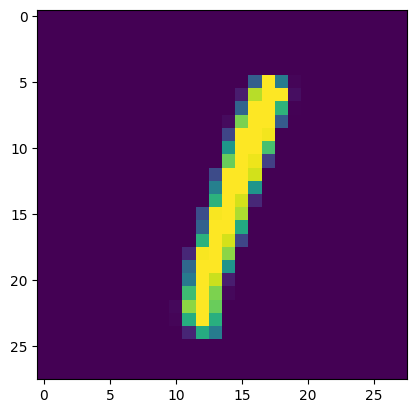

In [16]:
plt.imshow(x_test[5])

In [17]:
print(y_pred[5])

1


In [18]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9857 - loss: 0.0569


[0.05690435692667961, 0.9857000112533569]

In [19]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)

In [47]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)
cr

'              precision    recall  f1-score   support\n\n           0       0.79      0.49      0.60      1000\n           1       0.78      0.85      0.81      1000\n           2       0.68      0.34      0.45      1000\n           3       0.41      0.53      0.46      1000\n           4       0.56      0.56      0.56      1000\n           5       0.59      0.52      0.55      1000\n           6       0.75      0.71      0.73      1000\n           7       0.61      0.77      0.68      1000\n           8       0.70      0.83      0.76      1000\n           9       0.70      0.84      0.76      1000\n\n    accuracy                           0.64     10000\n   macro avg       0.66      0.64      0.64     10000\nweighted avg       0.66      0.64      0.64     10000\n'

In [21]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9857

In [23]:
# same for cifar dataset
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [24]:
x_train.shape

(50000, 32, 32, 3)

In [25]:
x_test.shape

(10000, 32, 32, 3)

In [26]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


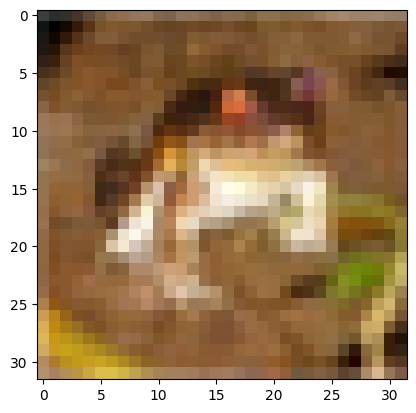

In [27]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])

In [28]:
x_train = x_train/255
x_test = x_test/255

In [34]:
# build cnn model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))
model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,418 (286.79 KB)

 Trainable params: 73,418 (286.79 KB)

 Non-trainable params: 0 (0.00 B)

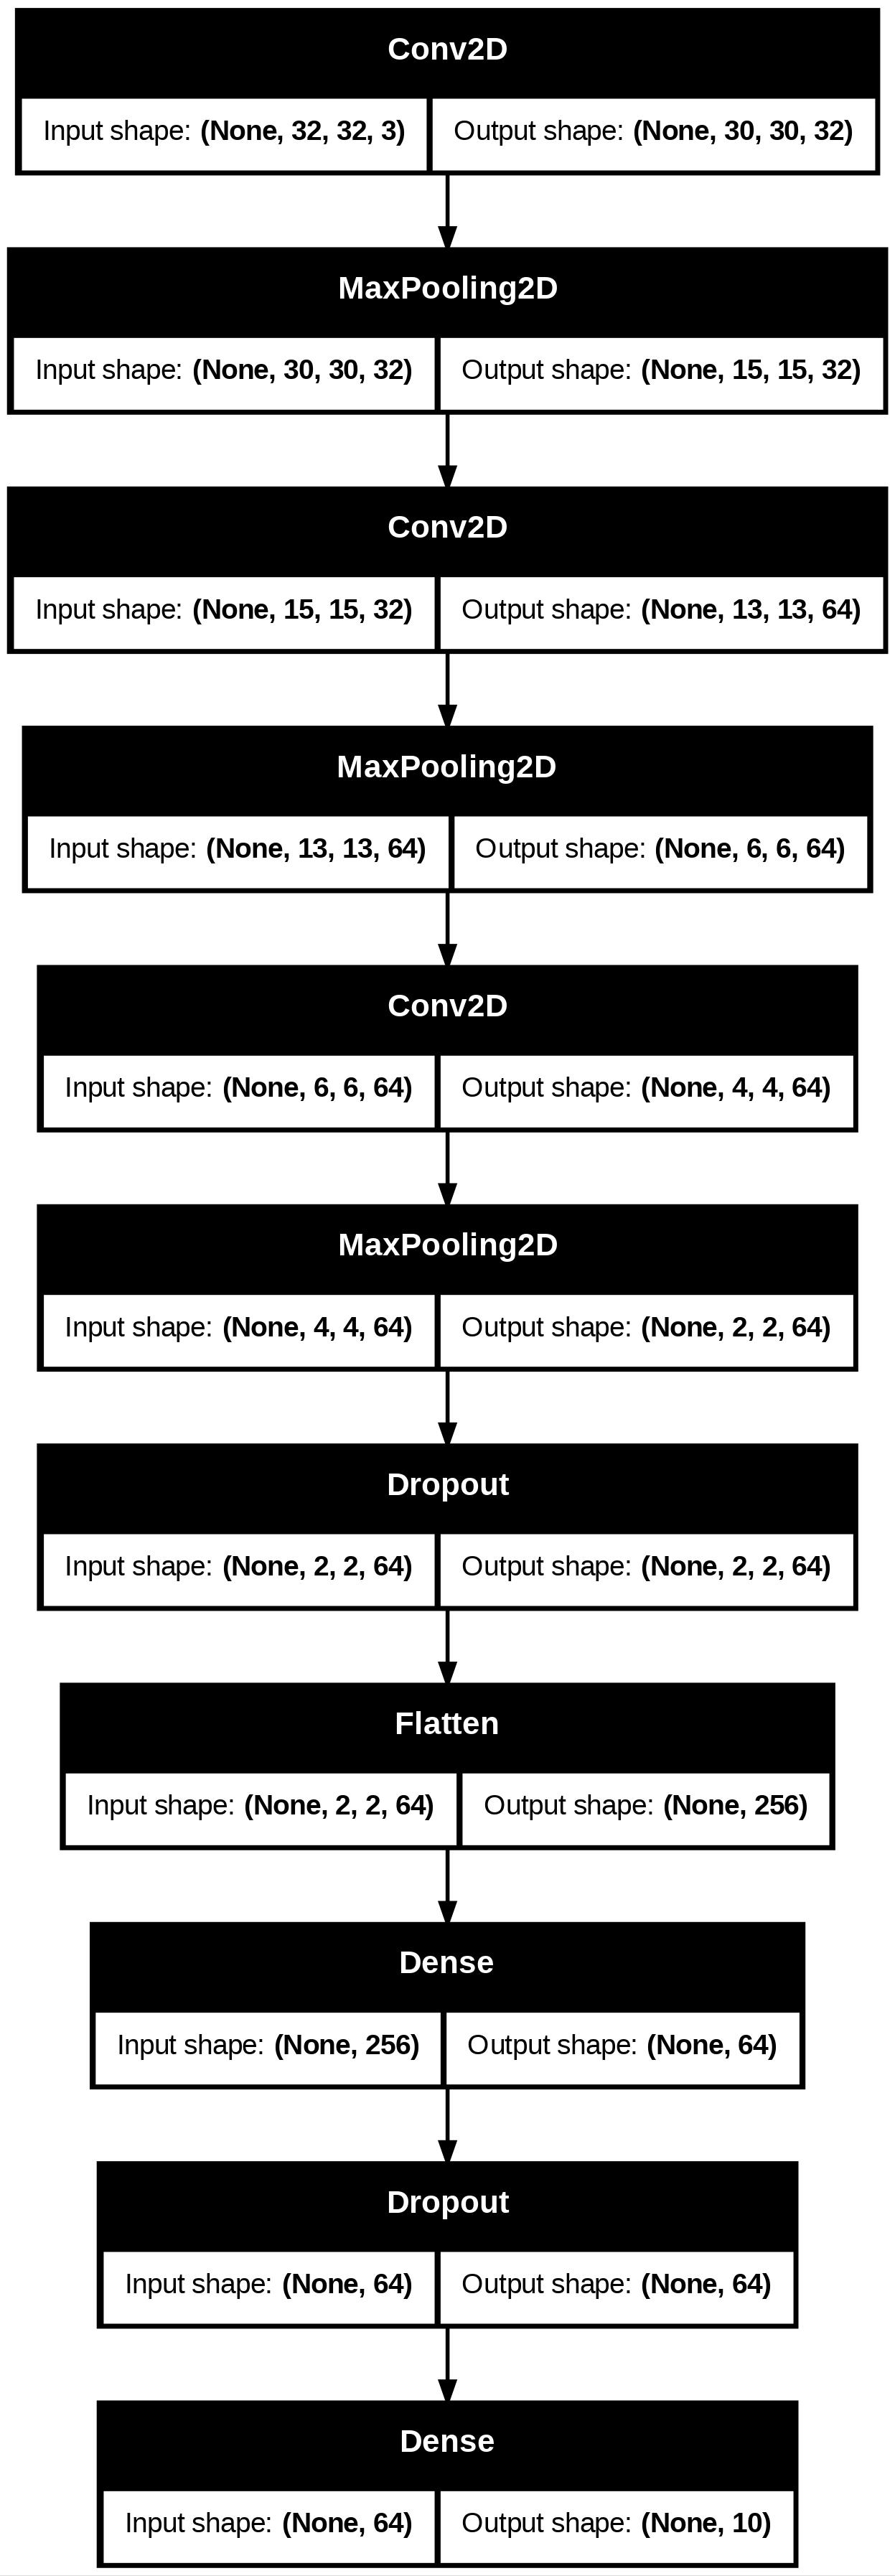

In [37]:
from keras.src.utils import plot_model
plot_model(model,'model.jpg',show_shapes=True)

In [38]:
model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - accuracy: 0.3102 - loss: 1.8347 - val_accuracy: 0.4595 - val_loss: 1.4725
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 45ms/step - accuracy: 0.4588 - loss: 1.4892 - val_accuracy: 0.5373 - val_loss: 1.2870
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.5141 - loss: 1.3560 - val_accuracy: 0.5531 - val_loss: 1.2429
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.5449 - loss: 1.2773 - val_accuracy: 0.6019 - val_loss: 1.1230
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.5685 - loss: 1.2204 - val_accuracy: 0.6227 - val_loss: 1.0729
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.5916 - loss: 1.1637 - val_accuracy: 0.6292 - val_loss: 1.0385
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 56s 45ms/step - accuracy: 0.6023 - loss: 1.1259 - val_accuracy: 0.6395 - val_loss: 1.0179
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 47ms/step - accuracy: 0.6204 -

In [39]:
y_pred=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


In [40]:
y_pred =y_pred.argmax(axis=1)

In [41]:
y_pred

array([3, 8, 8, ..., 5, 1, 7])

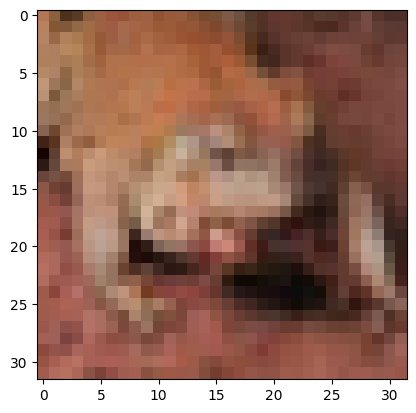

In [42]:
plt.imshow(x_test[5])

In [43]:
print(y_pred[5])

6


In [44]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6446 - loss: 0.9874


[0.9874363541603088, 0.644599974155426]

In [46]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[489,  61,  71,  34,  18,   6,   6,  30, 208,  77],
       [  5, 855,   1,   8,   2,   1,   5,   1,  33,  89],
       [ 49,  22, 340, 143, 168,  74,  75,  77,  32,  20],
       [  8,  20,  23, 533,  63, 173,  65,  62,  23,  30],
       [ 14,   5,  27,  94, 562,  24,  59, 190,  11,  14],
       [  5,   8,  16, 265,  53, 517,  12,  91,   9,  24],
       [  1,   8,  14, 129,  80,  15, 711,  13,   8,  21],
       [ 10,   7,   7,  53,  49,  68,   4, 766,   5,  31],
       [ 29,  33,   1,  30,   4,   1,   2,   6, 834,  60],
       [  7,  80,   3,   9,   3,   2,   7,  15,  35, 839]])

In [48]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)
cr

'              precision    recall  f1-score   support\n\n           0       0.79      0.49      0.60      1000\n           1       0.78      0.85      0.81      1000\n           2       0.68      0.34      0.45      1000\n           3       0.41      0.53      0.46      1000\n           4       0.56      0.56      0.56      1000\n           5       0.59      0.52      0.55      1000\n           6       0.75      0.71      0.73      1000\n           7       0.61      0.77      0.68      1000\n           8       0.70      0.83      0.76      1000\n           9       0.70      0.84      0.76      1000\n\n    accuracy                           0.64     10000\n   macro avg       0.66      0.64      0.64     10000\nweighted avg       0.66      0.64      0.64     10000\n'

In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6446